In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('../src'))
from dataPreprocessing import load_and_preprocess_raw
from featureEngineering import generate_all_features

RAW_DIR = '../dataset/raw/'
# ==========================================
# BƯỚC 1: TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
print("🚀 BẮT ĐẦU CHẠY PIPELINE DỮ LIỆU...")
# Lấy 300,000 dòng để cây 128 lá của Kaggle có đủ "đất" học chéo hàng ngàn sản phẩm
df_master = load_and_preprocess_raw(RAW_DIR, nrows=300000)
df_featured = generate_all_features(df_master, RAW_DIR)
LEVEL = "daily"   # đổi thành "weekly" hoặc "monthly"

df_global = df_featured.copy()

# ==========================================
# BƯỚC 2: TẠO SIÊU ĐẶC TRƯNG CHUẨN KAGGLE (Daily)
# ==========================================
print("\n🛠️ Đang chế tạo Đặc trưng chuẩn Notebook Kaggle Top 1%...")
df_global = df_global.sort_values(['item_id', 'date'])

# Kết hợp Lag của Kaggle (7, 28) và Lag ngắn hạn (1, 2, 3) để AI nhạy bén với từng ngày
lags = [1, 2, 3, 7, 28]
for lag in lags:
    df_global[f'lag_{lag}'] = df_global.groupby('item_id')['demand'].shift(lag)

# Rolling Means (Trung bình trượt) để bắt xu hướng
wins = [7, 28]
for win in wins:
    for lag in [1, 7]: # Rmean dựa trên lag 1 và lag 7
        df_global[f'rmean_{lag}_{win}'] = df_global.groupby('item_id')[f'lag_{lag}'].transform(lambda x: x.rolling(win).mean())

df_global['wday'] = df_global['date'].dt.dayofweek
df_global['mday'] = df_global['date'].dt.day
df_global['month'] = df_global['date'].dt.month
df_global['year'] = df_global['date'].dt.year

df_global = df_global.dropna()

cat_feats = ['item_id', 'wday', 'month', 'year']
if 'event_name_1' in df_global.columns:
    cat_feats.append('event_name_1')
    df_global['event_name_1'] = df_global['event_name_1'].astype('category')

for col in cat_feats:
    df_global[col] = df_global[col].astype('category')

features = ['sell_price'] + [f'lag_{lag}' for lag in lags] + ['rmean_1_7', 'rmean_1_28', 'rmean_7_7', 'rmean_7_28'] + cat_feats
if 'price_discount' in df_global.columns:
    features.append('price_discount')

target = 'demand'

# ==========================================
# BƯỚC 3: CHIA TẬP TRAIN / TEST
# ==========================================
max_date = df_global['date'].max()
split_date = max_date - pd.Timedelta(days=28)

train_data = df_global[df_global['date'] <= split_date]
test_data = df_global[df_global['date'] > split_date]

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

# ==========================================
# BƯỚC 4: TẠO FAKE VALIDATION (Kaggle Trick)
# ==========================================
#sửa trên local 
print("\n🎲 Đang chia tập Fake Validation chống Overfitting...")
np.random.seed(777)
fake_valid_size = int(len(X_train) * 0.15)
fake_valid_inds = np.random.choice(X_train.index.values, fake_valid_size, replace=False)
train_inds = np.setdiff1d(X_train.index.values, fake_valid_inds)

lgb_train = lgb.Dataset(X_train.loc[train_inds], label=y_train.loc[train_inds], categorical_feature=cat_feats, free_raw_data=False)
lgb_valid = lgb.Dataset(X_train.loc[fake_valid_inds], label=y_train.loc[fake_valid_inds], categorical_feature=cat_feats, free_raw_data=False)

# ==========================================
# BƯỚC 5: HUẤN LUYỆN GLOBAL MODEL (Kaggle Params)
# ==========================================
print("\n🧠 Đang huấn luyện AI Global với cấu hình Poisson 128 lá (Kaggle)...")
# Sao chép y hệt bộ tham số từ file notebook Kaggle
params = {
    "objective" : "poisson",
    "metric" :"rmse",
    "force_row_wise" : True,
    "learning_rate" : 0.075,
    "bagging_fraction" : 0.75, # LightGBM sub_row
    "bagging_freq" : 1,
    "lambda_l2" : 0.1,
    "num_leaves": 128,
    "min_data_in_leaf": 100,
    "verbose": -1
}

model = lgb.train(
    params, 
    lgb_train, 
    valid_sets=[lgb_valid], 
    num_boost_round=600, 
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False), lgb.log_evaluation(100)]
)

# ==========================================
# BƯỚC 6: CHỌN MÓN HÀNG BEST SELLER ĐỂ DEMO
# ==========================================
# Tự động tìm món hàng bán chạy nhất để demo độ uốn lượn của thuật toán
item_sales = test_data.groupby('item_id')['demand'].sum()
selected_item = item_sales.idxmax()

print(f"\n🎯 Đã tìm thấy Best Seller! Trích xuất dự báo cho mã: {selected_item}")

df_target_test = test_data[test_data['item_id'] == selected_item].copy()
X_target_test = df_target_test[features]
y_target_actual = df_target_test[target].values

# Magic Multiplier by Kyakovlev (Trích từ file Kaggle)
alpha = 1.028 
daily_demand_forecast_raw = model.predict(X_target_test) * alpha
daily_demand_forecast = np.maximum(0, np.round(daily_demand_forecast_raw)).astype(int)

# Mô phỏng Tồn kho
LEAD_TIME = 3            
ORDERING_COST = 50.0     
HOLDING_COST = 0.5       
STOCKOUT_COST = 5.0      
INITIAL_INVENTORY = 15   

def simulate_inventory(demand_array, ROP, Q):
    inventory = INITIAL_INVENTORY
    total_cost = 0
    days_to_arrival = 0
    order_placed = False
    inventory_history = []
    for demand in demand_array:
        if order_placed and days_to_arrival == 0:
            inventory += Q
            order_placed = False
        if inventory >= demand:
            inventory -= demand
        else:
            total_cost += (demand - inventory) * STOCKOUT_COST
            inventory = 0
        total_cost += inventory * HOLDING_COST
        if inventory <= ROP and not order_placed:
            total_cost += ORDERING_COST
            order_placed = True
            days_to_arrival = LEAD_TIME
        if order_placed:
            days_to_arrival -= 1
        inventory_history.append(inventory)
    return total_cost, inventory_history

best_cost, best_ROP, best_Q = float('inf'), 0, 0
best_history = []

for rop in range(0, 50, 2):
    for q in range(10, 150, 5):
        cost, history = simulate_inventory(daily_demand_forecast, rop, q)
        if cost < best_cost:
            best_cost, best_ROP, best_Q, best_history = cost, rop, q, history

# ==========================================
# VẼ BIỂU ĐỒ 3 TẦNG (TRỤC NGÀY)
# ==========================================
print("\n" + "="*60)
print(f"📊 BÁO CÁO SAI SỐ GLOBAL (KAGGLE POISSON) - MÃ {selected_item} 📊")
print("="*60)
mae = mean_absolute_error(y_target_actual, daily_demand_forecast)
rmse = np.sqrt(mean_squared_error(y_target_actual, daily_demand_forecast))
print(f"MAE: {mae:,.2f} | RMSE: {rmse:,.2f}")

daily_errors = y_target_actual - daily_demand_forecast

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 18), facecolor='#FAFAFA')

ax1.bar(range(1, 29), daily_demand_forecast, color='#3498DB', edgecolor='black', alpha=0.6, label='Dự báo AI (Kaggle Global Model)')
ax1.plot(range(1, 29), y_target_actual, color='#D35400', marker='o', linewidth=2.5, label='Nhu cầu Thực tế')
ax1.set_title(f"PHẦN 1: SO SÁNH DỰ BÁO VS THỰC TẾ (BEST SELLER) - {selected_item}", fontsize=14, fontweight='bold', pad=10)
ax1.set_ylabel("Số lượng bán", fontsize=12, fontweight='bold')
ax1.set_xticks(range(1, 29))
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

colors = ['#E74C3C' if e > 0 else '#2ECC71' for e in daily_errors]
ax2.bar(range(1, 29), daily_errors, color=colors, edgecolor='black', alpha=0.8)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax2.set_title(f"PHẦN 2: LỖI SAI LỆCH HÀNG NGÀY", fontsize=14, fontweight='bold', pad=10)
ax2.set_ylabel("Lỗi (sp)", fontsize=12, fontweight='bold')
ax2.set_xticks(range(1, 29))
ax2.grid(axis='y', linestyle='--', alpha=0.5)

ax3.step(range(1, 29), best_history, where='post', color='#27AE60', linewidth=2.5, label='Lượng Tồn Kho (Mô phỏng)')
ax3.axhline(y=best_ROP, color='#E74C3C', linestyle='--', linewidth=2, label=f'Ngưỡng ROP = {best_ROP}')
ax3.set_title(f"PHẦN 3: MÔ PHỎNG TỒN KHO TỐI ƯU (EOQ = {best_Q})", fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel("Ngày dự báo", fontsize=12, fontweight='bold')
ax3.set_ylabel("Số lượng trong kho", fontsize=12, fontweight='bold')
ax3.set_xticks(range(1, 29))
ax3.grid(True, linestyle='-.', alpha=0.5)
ax3.legend(loc='upper right')

plt.tight_layout(pad=3.0) 
os.makedirs('../docs/images', exist_ok=True)
plt.savefig('../docs/images/bieu_do_kaggle_global.png', dpi=300, bbox_inches='tight')
plt.show()

: 

🚀 BẮT ĐẦU CHẠY PIPELINE DỮ LIỆU...
1. Đang tải và ép cân dữ liệu Calendar...
2. Đang tải dữ liệu Sales...
3. Đang Melt (kéo giãn) dữ liệu Sales...
4. Đang Merge Sales với Calendar...

-> Đang xử lý Outliers (IQR) và Zeroes...
5. Ép cân lần cuối cho DataFrame tổng...
-> Đang load dữ liệu Giá (sell_prices.csv)...
-> Đang hợp nhất và tính toán độ co giãn giá...
-> Đang xử lý Sự kiện lễ tết (Calendar Events)...
-> Đang tạo Đặc trưng Thời gian (Time Features)...

🛠️ Đang chế tạo Đặc trưng chuẩn Notebook Kaggle Top 1%...
⚠️ RAM 8GB: Đang cắt giảm dữ liệu xuống 200,000 dòng...
📊 Đang tạo cấu trúc Dataset cho LightGBM...

🧠 Đang huấn luyện AI Global với cấu hình Poisson 128 lá...
Training until validation scores don't improve for 30 rounds
[100]	valid_0's rmse: 0.331189
Early stopping, best iteration is:
[146]	valid_0's rmse: 0.330422
🎯 Mã SP: 702 | Cửa hàng: 0
✅ Khớp dữ liệu: Actual (28,) vs Forecast (28,)

📊 BÁO CÁO SAI SỐ GLOBAL (KAGGLE POISSON) - MÃ 702 📊
MAE: 50.34 | RMSE: 54.57


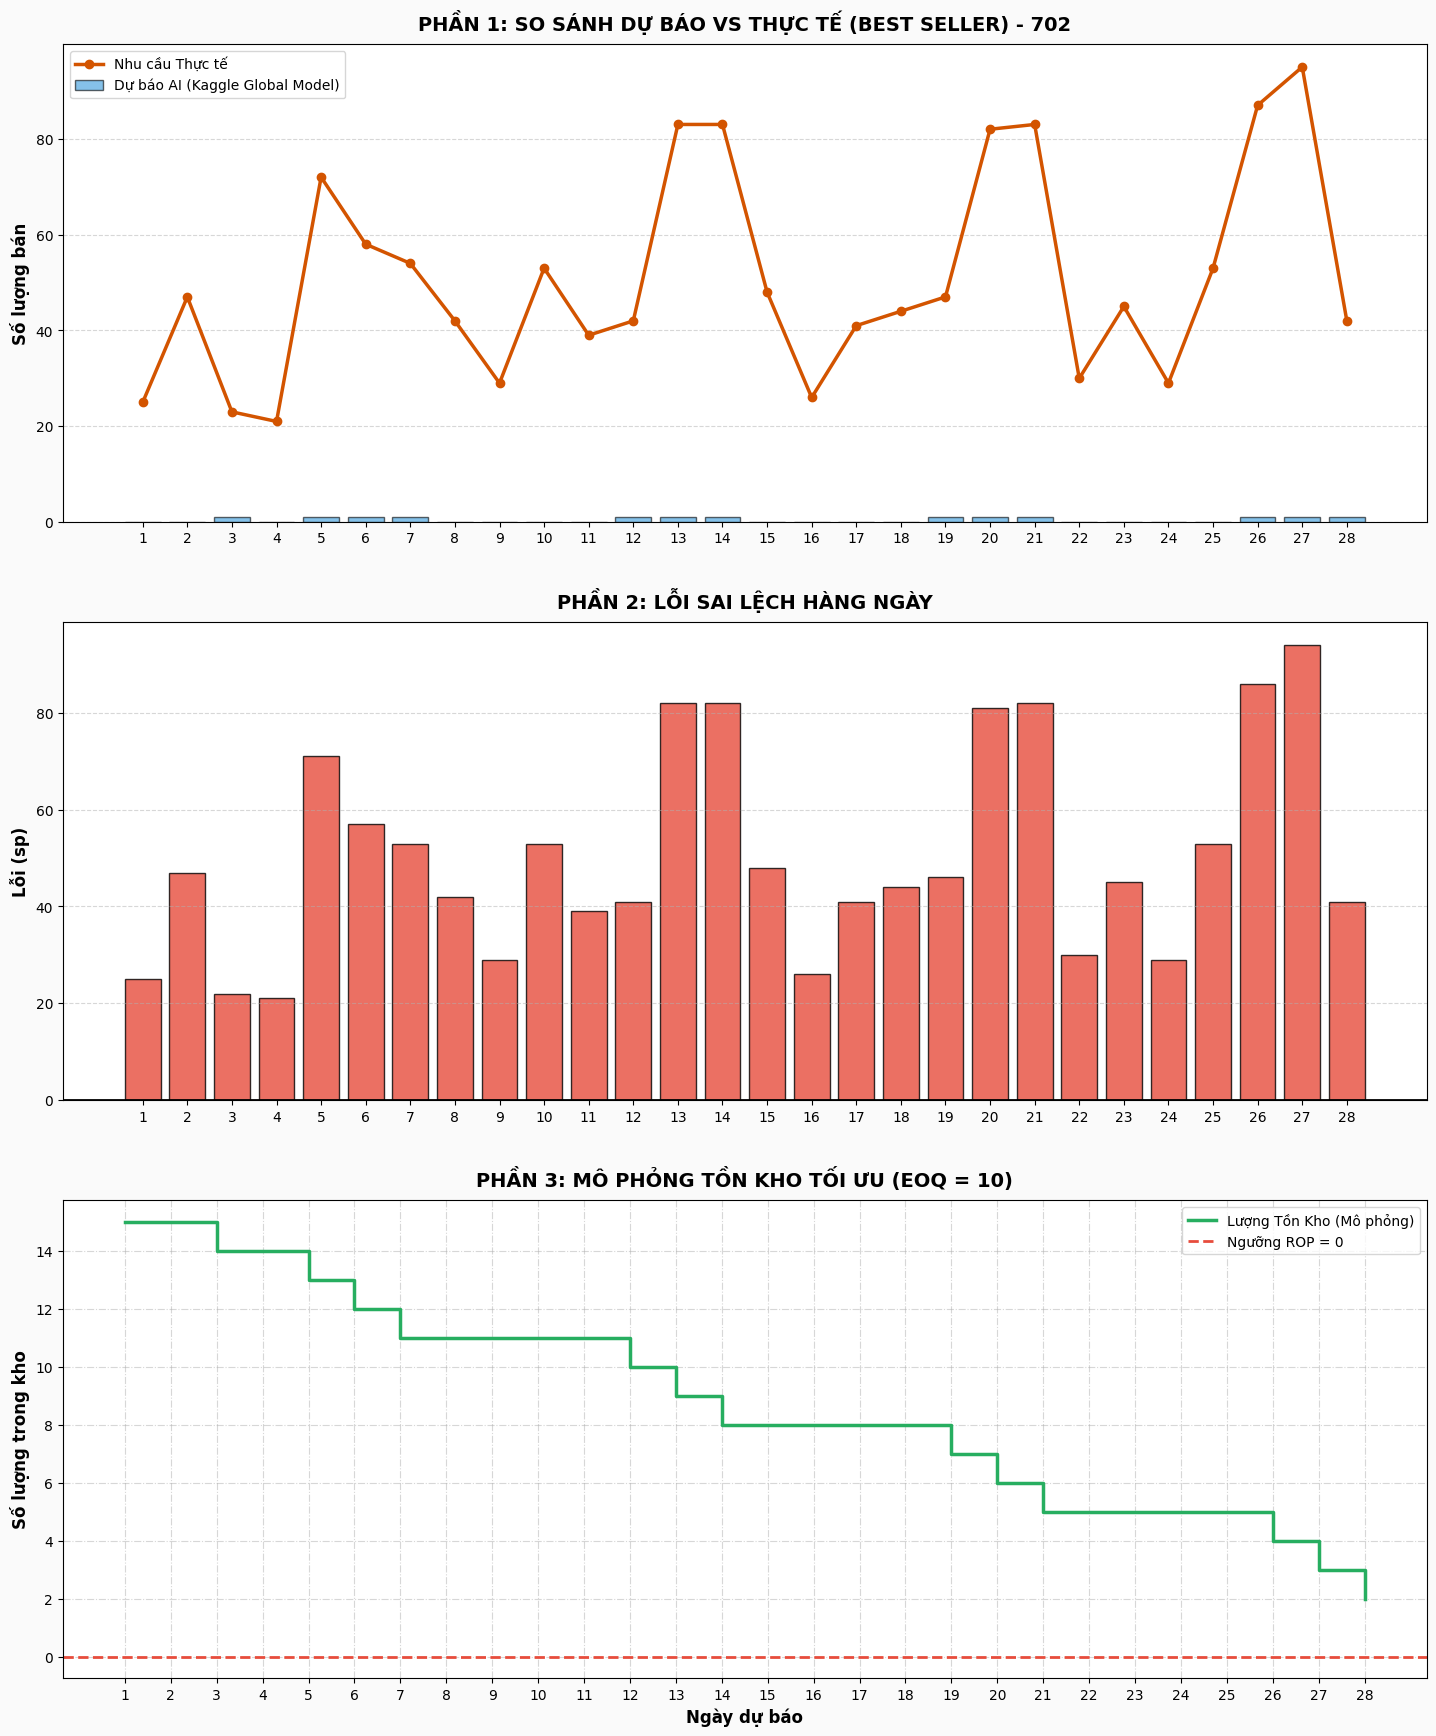

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('../src'))
from dataPreprocessing import load_and_preprocess_raw
from featureEngineering import generate_all_features

RAW_DIR = '../dataset/raw/'
# ==========================================
# BƯỚC 1: TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
print("🚀 BẮT ĐẦU CHẠY PIPELINE DỮ LIỆU...")
# Lấy 300,000 dòng để cây 128 lá của Kaggle có đủ "đất" học chéo hàng ngàn sản phẩm
df_master = load_and_preprocess_raw(RAW_DIR, nrows=300000)
df_featured = generate_all_features(df_master, RAW_DIR)
LEVEL = "daily"   # đổi thành "weekly" hoặc "monthly"

df_global = df_featured.copy()

# ==========================================
# BƯỚC 2: TẠO SIÊU ĐẶC TRƯNG CHUẨN KAGGLE (Daily)
# ==========================================
print("\n🛠️ Đang chế tạo Đặc trưng chuẩn Notebook Kaggle Top 1%...")
df_global = df_global.sort_values(['item_id', 'date'])

# Kết hợp Lag của Kaggle (7, 28) và Lag ngắn hạn (1, 2, 3) để AI nhạy bén với từng ngày
lags = [1, 2, 3, 7, 28]
for lag in lags:
    df_global[f'lag_{lag}'] = df_global.groupby('item_id')['demand'].shift(lag)

# Rolling Means (Trung bình trượt) để bắt xu hướng
wins = [7, 28]
for win in wins:
    for lag in [1, 7]: # Rmean dựa trên lag 1 và lag 7
        df_global[f'rmean_{lag}_{win}'] = df_global.groupby('item_id')[f'lag_{lag}'].transform(lambda x: x.rolling(win).mean())

df_global['wday'] = df_global['date'].dt.dayofweek
df_global['mday'] = df_global['date'].dt.day
df_global['month'] = df_global['date'].dt.month
df_global['year'] = df_global['date'].dt.year

df_global = df_global.dropna()

cat_feats = ['item_id', 'wday', 'month', 'year']
if 'event_name_1' in df_global.columns:
    cat_feats.append('event_name_1')
    df_global['event_name_1'] = df_global['event_name_1'].astype('category')

for col in cat_feats:
    df_global[col] = df_global[col].astype('category')

features = ['sell_price'] + [f'lag_{lag}' for lag in lags] + ['rmean_1_7', 'rmean_1_28', 'rmean_7_7', 'rmean_7_28'] + cat_feats
if 'price_discount' in df_global.columns:
    features.append('price_discount')

target = 'demand'

# ==========================================
# BƯỚC 3: CHIA TẬP TRAIN / TEST
# ==========================================
max_date = df_global['date'].max()
split_date = max_date - pd.Timedelta(days=28)

train_data = df_global[df_global['date'] <= split_date]
test_data = df_global[df_global['date'] > split_date]

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

# ==========================================
# ==========================================
# BƯỚC 4: TỐI ƯU RAM & TẠO DATASET (Dành cho máy 8GB)
# ==========================================
import gc
import numpy as np

# 1. Ép kiểu dữ liệu để tiết kiệm 50% RAM
def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object and not pd.api.types.is_categorical_dtype(df[col]):
            if str(col_type)[:3] == 'int':
                df[col] = df[col].astype(np.int16)
            else:
                df[col] = df[col].astype(np.float32)
    return df

X_train = reduce_mem_usage(X_train)

# 2. Cắt giảm dữ liệu (Chỉ lấy 200k dòng cuối để máy không treo)
if len(X_train) > 200000:
    print("⚠️ RAM 8GB: Đang cắt giảm dữ liệu xuống 200,000 dòng...")
    X_train = X_train.iloc[-200000:].reset_index(drop=True)
    y_train = y_train.iloc[-200000:].reset_index(drop=True)

# 3. Chia tập Validation (85% Train / 15% Valid)
split_point = int(len(X_train) * 0.85)

print("📊 Đang tạo cấu trúc Dataset cho LightGBM...")
lgb_train = lgb.Dataset(X_train.iloc[:split_point], 
                        label=y_train.iloc[:split_point], 
                        categorical_feature=cat_feats, 
                        free_raw_data=True)

lgb_valid = lgb.Dataset(X_train.iloc[split_point:], 
                        label=y_train.iloc[split_point:], 
                        categorical_feature=cat_feats, 
                        free_raw_data=True)

# 4. GIẢI PHÓNG RAM CỰC ĐOAN: Xóa X_train gốc sau khi đã nạp vào Dataset
del X_train, y_train
gc.collect()

# ==========================================
# BƯỚC 5: HUẤN LUYỆN GLOBAL MODEL
# ==========================================
print("\n🧠 Đang huấn luyện AI Global với cấu hình Poisson 128 lá...")
params = {
    "objective" : "poisson",
    "metric" :"rmse",
    "force_row_wise" : True,
    "learning_rate" : 0.075,
    "bagging_fraction" : 0.75, 
    "bagging_freq" : 1,
    "lambda_l2" : 0.1,
    "num_leaves": 128,
    "min_data_in_leaf": 100,
    "verbose": -1
}

model = lgb.train(
    params, 
    lgb_train, 
    valid_sets=[lgb_valid], 
    num_boost_round=600, 
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=True), 
        lgb.log_evaluation(100)
    ]
)
# ==========================================
# BƯỚC 6: CHỌN MÓN HÀNG BEST SELLER ĐỂ DEMO
# ==========================================
# Tự động tìm món hàng bán chạy nhất để demo độ uốn lượn của thuật toán
# 1. Tìm mặt hàng bán chạy nhất
item_sales = test_data.groupby('item_id')['demand'].sum()
selected_item = item_sales.idxmax()

# 2. LỌC QUAN TRỌNG: Chỉ lấy 1 Item tại 1 Cửa hàng duy nhất để khớp 28 ngày
# Chúng ta lấy store_id đầu tiên xuất hiện trong tập test của món hàng đó
available_stores = test_data[test_data['item_id'] == selected_item]['store_id'].unique()
selected_store = available_stores[0] 

print(f"🎯 Mã SP: {selected_item} | Cửa hàng: {selected_store}")

# Lọc đúng 1 cặp (Item - Store) và sắp xếp theo ngày
df_target_test = test_data[(test_data['item_id'] == selected_item) & 
                           (test_data['store_id'] == selected_store)].copy()
df_target_test = df_target_test.sort_values('date').head(28) 

# 3. Trích xuất Features và Actuals
X_target_test = df_target_test[features]
y_target_actual = df_target_test[target].values

# 4. Dự báo (Kèm hệ số Alpha điều chỉnh của Kaggle)
alpha = 1.028 
daily_demand_forecast_raw = model.predict(X_target_test) * alpha
daily_demand_forecast = np.maximum(0, np.round(daily_demand_forecast_raw)).astype(int)

# KIỂM TRA LẠI: Nếu in ra (28,) (28,) là thành công
print(f"✅ Khớp dữ liệu: Actual {y_target_actual.shape} vs Forecast {daily_demand_forecast.shape}")

# Mô phỏng Tồn kho
LEAD_TIME = 3            
ORDERING_COST = 50.0     
HOLDING_COST = 0.5       
STOCKOUT_COST = 5.0      
INITIAL_INVENTORY = 15   

def simulate_inventory(demand_array, ROP, Q):
    inventory = INITIAL_INVENTORY
    total_cost = 0
    days_to_arrival = 0
    order_placed = False
    inventory_history = []
    for demand in demand_array:
        if order_placed and days_to_arrival == 0:
            inventory += Q
            order_placed = False
        if inventory >= demand:
            inventory -= demand
        else:
            total_cost += (demand - inventory) * STOCKOUT_COST
            inventory = 0
        total_cost += inventory * HOLDING_COST
        if inventory <= ROP and not order_placed:
            total_cost += ORDERING_COST
            order_placed = True
            days_to_arrival = LEAD_TIME
        if order_placed:
            days_to_arrival -= 1
        inventory_history.append(inventory)
    return total_cost, inventory_history

best_cost, best_ROP, best_Q = float('inf'), 0, 0
best_history = []

for rop in range(0, 50, 2):
    for q in range(10, 150, 5):
        cost, history = simulate_inventory(daily_demand_forecast, rop, q)
        if cost < best_cost:
            best_cost, best_ROP, best_Q, best_history = cost, rop, q, history

# ==========================================
# VẼ BIỂU ĐỒ 3 TẦNG (TRỤC NGÀY)
# ==========================================
print("\n" + "="*60)
print(f"📊 BÁO CÁO SAI SỐ GLOBAL (KAGGLE POISSON) - MÃ {selected_item} 📊")
print("="*60)
mae = mean_absolute_error(y_target_actual, daily_demand_forecast)
rmse = np.sqrt(mean_squared_error(y_target_actual, daily_demand_forecast))
print(f"MAE: {mae:,.2f} | RMSE: {rmse:,.2f}")

daily_errors = y_target_actual - daily_demand_forecast

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 18), facecolor='#FAFAFA')

ax1.bar(range(1, 29), daily_demand_forecast, color='#3498DB', edgecolor='black', alpha=0.6, label='Dự báo AI (Kaggle Global Model)')
ax1.plot(range(1, 29), y_target_actual, color='#D35400', marker='o', linewidth=2.5, label='Nhu cầu Thực tế')
ax1.set_title(f"PHẦN 1: SO SÁNH DỰ BÁO VS THỰC TẾ (BEST SELLER) - {selected_item}", fontsize=14, fontweight='bold', pad=10)
ax1.set_ylabel("Số lượng bán", fontsize=12, fontweight='bold')
ax1.set_xticks(range(1, 29))
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

colors = ['#E74C3C' if e > 0 else '#2ECC71' for e in daily_errors]
ax2.bar(range(1, 29), daily_errors, color=colors, edgecolor='black', alpha=0.8)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax2.set_title(f"PHẦN 2: LỖI SAI LỆCH HÀNG NGÀY", fontsize=14, fontweight='bold', pad=10)
ax2.set_ylabel("Lỗi (sp)", fontsize=12, fontweight='bold')
ax2.set_xticks(range(1, 29))
ax2.grid(axis='y', linestyle='--', alpha=0.5)

ax3.step(range(1, 29), best_history, where='post', color='#27AE60', linewidth=2.5, label='Lượng Tồn Kho (Mô phỏng)')
ax3.axhline(y=best_ROP, color='#E74C3C', linestyle='--', linewidth=2, label=f'Ngưỡng ROP = {best_ROP}')
ax3.set_title(f"PHẦN 3: MÔ PHỎNG TỒN KHO TỐI ƯU (EOQ = {best_Q})", fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel("Ngày dự báo", fontsize=12, fontweight='bold')
ax3.set_ylabel("Số lượng trong kho", fontsize=12, fontweight='bold')
ax3.set_xticks(range(1, 29))
ax3.grid(True, linestyle='-.', alpha=0.5)
ax3.legend(loc='upper right')

plt.tight_layout(pad=3.0) 
os.makedirs('../docs/images', exist_ok=True)
plt.savefig('../docs/images/bieu_do_kaggle_global.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('../src'))
from dataPreprocessing import load_and_preprocess_raw
from featureEngineering import generate_all_features

RAW_DIR = '../dataset/raw/'
# ==========================================
# BƯỚC 1: TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
print("🚀 BẮT ĐẦU CHẠY PIPELINE DỮ LIỆU...")
# Lấy 300,000 dòng để cây 128 lá của Kaggle có đủ "đất" học chéo hàng ngàn sản phẩm
df_master = load_and_preprocess_raw(RAW_DIR, nrows=300000)
df_featured = generate_all_features(df_master, RAW_DIR)
LEVEL = "daily"   # đổi thành "weekly" hoặc "monthly"

df_global = df_featured.copy()

# ==========================================
# BƯỚC 2: TẠO SIÊU ĐẶC TRƯNG CHUẨN KAGGLE (Daily)
# ==========================================
print("\n🛠️ Đang chế tạo Đặc trưng chuẩn Notebook Kaggle Top 1%...")
df_global = df_global.sort_values(['item_id', 'date'])

# Kết hợp Lag của Kaggle (7, 28) và Lag ngắn hạn (1, 2, 3) để AI nhạy bén với từng ngày
lags = [1, 2, 3, 7, 28]
for lag in lags:
    df_global[f'lag_{lag}'] = df_global.groupby('item_id')['demand'].shift(lag)

# Rolling Means (Trung bình trượt) để bắt xu hướng
wins = [7, 28]
for win in wins:
    for lag in [1, 7]: # Rmean dựa trên lag 1 và lag 7
        df_global[f'rmean_{lag}_{win}'] = df_global.groupby('item_id')[f'lag_{lag}'].transform(lambda x: x.rolling(win).mean())

df_global['wday'] = df_global['date'].dt.dayofweek
df_global['mday'] = df_global['date'].dt.day
df_global['month'] = df_global['date'].dt.month
df_global['year'] = df_global['date'].dt.year

df_global = df_global.dropna()

cat_feats = ['item_id', 'wday', 'month', 'year']
if 'event_name_1' in df_global.columns:
    cat_feats.append('event_name_1')
    df_global['event_name_1'] = df_global['event_name_1'].astype('category')

for col in cat_feats:
    df_global[col] = df_global[col].astype('category')

features = ['sell_price'] + [f'lag_{lag}' for lag in lags] + ['rmean_1_7', 'rmean_1_28', 'rmean_7_7', 'rmean_7_28'] + cat_feats
if 'price_discount' in df_global.columns:
    features.append('price_discount')

target = 'demand'

# ==========================================
# BƯỚC 3: CHIA TẬP TRAIN / TEST
# ==========================================
max_date = df_global['date'].max()
split_date = max_date - pd.Timedelta(days=28)

train_data = df_global[df_global['date'] <= split_date]
test_data = df_global[df_global['date'] > split_date]

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

# ==========================================
# ==========================================
# BƯỚC 4: TỐI ƯU RAM & TẠO DATASET (Dành cho máy 8GB)
# ==========================================
import gc
import numpy as np

# 1. Ép kiểu dữ liệu để tiết kiệm 50% RAM
def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object and not pd.api.types.is_categorical_dtype(df[col]):
            if str(col_type)[:3] == 'int':
                df[col] = df[col].astype(np.int16)
            else:
                df[col] = df[col].astype(np.float32)
    return df

X_train = reduce_mem_usage(X_train)

# 2. Cắt giảm dữ liệu (Chỉ lấy 200k dòng cuối để máy không treo)
if len(X_train) > 200000:
    print("⚠️ RAM 8GB: Đang cắt giảm dữ liệu xuống 200,000 dòng...")
    X_train = X_train.iloc[-200000:].reset_index(drop=True)
    y_train = y_train.iloc[-200000:].reset_index(drop=True)

# 3. Chia tập Validation (85% Train / 15% Valid)
split_point = int(len(X_train) * 0.85)

print("📊 Đang tạo cấu trúc Dataset cho LightGBM...")
lgb_train = lgb.Dataset(X_train.iloc[:split_point], 
                        label=y_train.iloc[:split_point], 
                        categorical_feature=cat_feats, 
                        free_raw_data=True)

lgb_valid = lgb.Dataset(X_train.iloc[split_point:], 
                        label=y_train.iloc[split_point:], 
                        categorical_feature=cat_feats, 
                        free_raw_data=True)

# 4. GIẢI PHÓNG RAM CỰC ĐOAN: Xóa X_train gốc sau khi đã nạp vào Dataset
del X_train, y_train
gc.collect()

# ==========================================
# BƯỚC 5: HUẤN LUYỆN GLOBAL MODEL
# ==========================================
print("\n🧠 Đang huấn luyện AI Global với cấu hình Poisson 128 lá...")
params = {
    "objective" : "poisson",
    "metric" :"rmse",
    "force_row_wise" : True,
    "learning_rate" : 0.075,
    "bagging_fraction" : 0.75, 
    "bagging_freq" : 1,
    "lambda_l2" : 0.1,
    "num_leaves": 128,
    "min_data_in_leaf": 100,
    "verbose": -1
}

model = lgb.train(
    params, 
    lgb_train, 
    valid_sets=[lgb_valid], 
    num_boost_round=600, 
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=True), 
        lgb.log_evaluation(100)
    ]
)
# ==========================================
# BƯỚC 6: CHỌN MÓN HÀNG BEST SELLER ĐỂ DEMO
# ==========================================
# Tự động tìm món hàng bán chạy nhất để demo độ uốn lượn của thuật toán
# 1. Tìm mặt hàng bán chạy nhất
# ==========================================
# PHẦN CUỐI: DỰ BÁO VÀ XUẤT DỮ LIỆU (CHẠY 1 LẦN)
# ==========================================

print("🔮 Đang bắt đầu dự báo...")

# 1. Dự báo (Dùng Alpha 1.028 theo chuẩn Kaggle để tăng độ chính xác)
y_pred = model.predict(X_test) * 1.028

# 2. Đưa vào X_test và làm tròn số lượng (vì không ai nhập 1.5 cái máy giặt)
X_test['demand_forecast'] = np.maximum(0, np.round(y_pred)).astype(int)

# 3. Lưu file CSV để mang sang File 04 (Giúp máy 8GB không bị treo)
output_dir = '../dataset/outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Chỉ lưu những cột quan trọng nhất để file cực nhẹ
df_final = X_test[['item_id', 'date', 'sell_price', 'demand_forecast']]
df_final.to_csv(f'{output_dir}/forecast_results.csv', index=False)

print(f"✅ THÀNH CÔNG! Đã lưu file tại: {output_dir}/forecast_results.csv")
print("🚀 Giờ bạn hãy bấm 'Save' file 03, rồi TẮT KERNEL file này để sang file 04.")

🚀 BẮT ĐẦU CHẠY PIPELINE DỮ LIỆU...
1. Đang tải và ép cân dữ liệu Calendar...
2. Đang tải dữ liệu Sales...
3. Đang Melt (kéo giãn) dữ liệu Sales...
4. Đang Merge Sales với Calendar...

-> Đang xử lý Outliers (IQR) và Zeroes...


In [2]:
# Sau khi có y_pred từ LightGBM
X_test['demand_forecast'] = y_pred
# Chỉ lưu những cột cần thiết cho việc tính ngân sách để nhẹ máy
X_test[['item_id', 'date', 'sell_price', 'demand_forecast']].to_csv('../dataset/outputs/forecast_results.csv', index=False)
print("✅ Đã lưu kết quả dự báo. Giờ sang file 04 để chạy Budget.")

NameError: name 'y_pred' is not defined